In [30]:
import rainbow as rb
import numpy as np

datadir = rb.read("/Users/ccoatney/Library/CloudStorage/OneDrive-NREL/GC-MS code development/Hyewon's data/260224 GC1 R1 Run 311 outlet 25.D")
fid = datadir.get_file('FID1A.ch')

x = np.array(fid.xlabels)
y = np.array(fid.data).flatten()

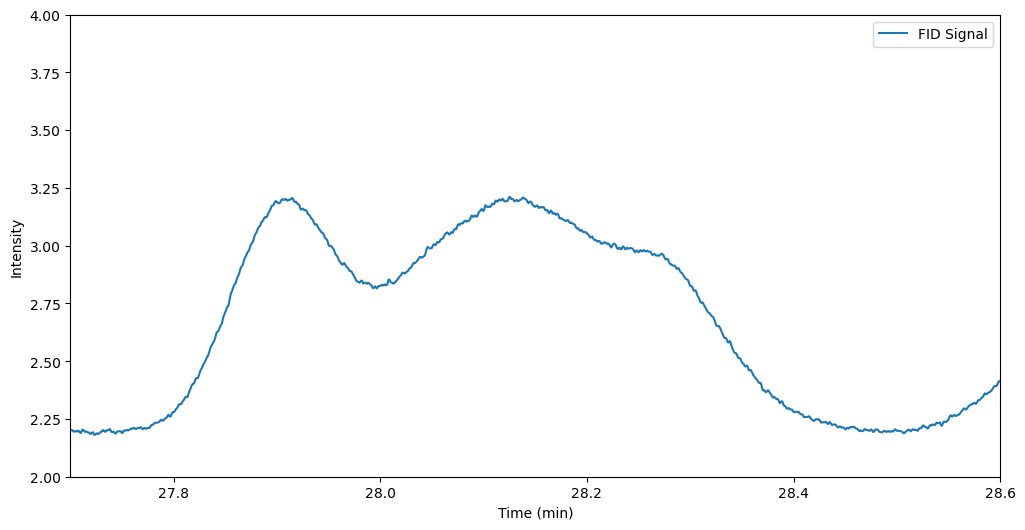

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(x, y, label='FID Signal')
plt.xlabel('Time (min)')
plt.ylabel('Intensity')
plt.xlim((27.7,28.6))
plt.ylim((2,4))
plt.legend()
plt.show()

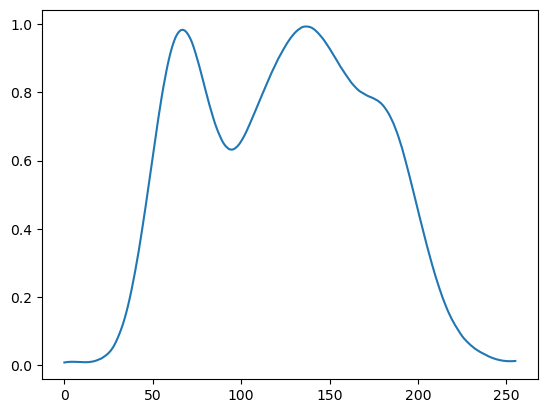

In [53]:
import torch
from scipy.signal import savgol_filter

peak_mask = (x >= 27.7) & (x <= 28.5)
#peak_mask = (x >= 24.27) & (x <= 24.55)
y_peak = y[peak_mask]

# interpolate to a 256 length vector for model input, scale to [0,1]
y_peak = np.interp(np.linspace(0, len(y_peak)-1, 256), np.arange(len(y_peak)), y_peak)
y_min = np.min(y_peak)
y_max = np.max(y_peak)
y_peak = (y_peak - y_min) / (y_max - y_min)

# apply Savitzky-Golay filter for smoothing
y_peak = savgol_filter(y_peak, window_length=35, polyorder=3)

# convert y_peak to tensor and add batch/channel dimensions
y_peak_tensor = torch.tensor(y_peak, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

plt.plot(y_peak)
plt.show()

In [45]:
from unet_model import GCHeatmapUNet

model = GCHeatmapUNet()
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")
model = model.to(device)
model.load_state_dict(torch.load("gc_heatmap_unet.pth"))
print("Pre-trained model loaded successfully.")

Using device: mps
Pre-trained model loaded successfully.


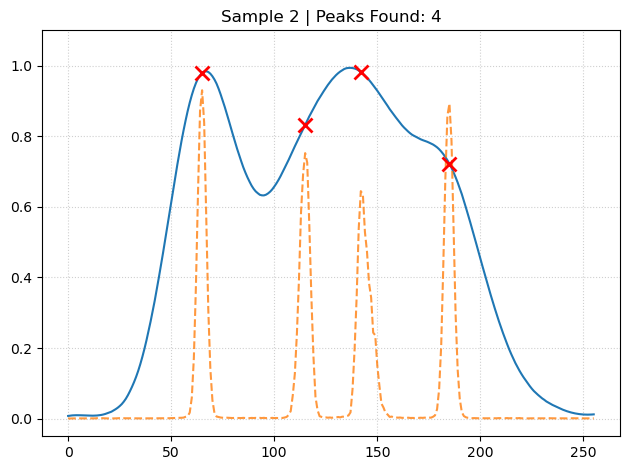

In [54]:
from scipy.signal import find_peaks

model.eval()
with torch.no_grad():
    predictions = model(y_peak_tensor.to(device))

# Convert back to NumPy (N, L, C) for plotting
predictions_np = predictions.cpu().permute(0, 2, 1).numpy()

fig, ax = plt.subplots()

signal = y_peak_tensor.cpu().numpy()[0, 0, :]
heatmap_pred = predictions_np[0, :, 0]

# --- The Key Extraction Step ---
# We search the predicted heatmap for peaks.
# Height filters out low-probability noise; distance prevents double-counting a wide blob.
apex_indices, _ = find_peaks(heatmap_pred, height=0.15, distance=10)

# Plot the original noisy GC signal
ax.plot(signal, label='Raw Signal', color='#1f77b4', linewidth=1.5)

# Plot the model's predicted heatmap
ax.plot(heatmap_pred, label='Pred Heatmap', color='#ff7f0e', linestyle='--', alpha=0.8)

# Scatter plot red markers at the inferred apex locations
if len(apex_indices) > 0:
    ax.plot(apex_indices, signal[apex_indices], 'rx', 
            markersize=10, markeredgewidth=2, label='Inferred Apex')
    
# Clean up the plot aesthetics
ax.set_title(f"Sample {i+1} | Peaks Found: {len(apex_indices)}")
ax.set_ylim(-0.05, 1.1)
ax.grid(True, linestyle=':', alpha=0.6)

        
plt.tight_layout()
plt.show()